# Notebook 09 — Cross-Model Representational Drift: Novel Technique 6

**TIN-7: Cross-Lingual Embedding Alignment Analysis**

## Motivation

Notebook 08 showed that **Delta-CKA** (comparing the cross-lingual
similarity structure *within* each model) produces near-zero differences
between Tiny Aya's Global and Regional variants (~0.0001 avg). This is
because CKA measures whether *pairs of languages* have the same relative
similarity — and model merging preserves that structure almost perfectly.

Yet the Tiny Aya tech report shows real functional improvements: regional
models improve translation quality by up to +5.5 ChrF for their target
languages. The representational changes must exist — we just need a
metric sensitive enough to detect them.

## Hypothesis

**Regional fine-tuning makes targeted representational changes that
improve functional alignment for target languages without disrupting
overall cross-lingual geometry.**

Specifically, we predict:

1. **Cross-Model Representational Drift** (Part 1): Regional models
   should show higher drift for their target languages than for
   non-target languages, and drift should concentrate in later layers
   where the architecture uses global attention.
2. **Per-Language Retrieval MRR** (Part 2): Regional models should
   improve retrieval MRR for their target languages compared to the
   Global model, confirming that representational drift translates
   to functional improvement.
3. **Drift-MRR Correlation** (Part 3): Languages with higher
   representational drift should show larger MRR improvements,
   linking geometric change to functional gain.

## Novel techniques

- **Cross-Model CKA Drift**: `Drift(L, k) = 1 - CKA(global[L][k], regional[L][k])`
  — measures how much a language's representation shifts between models.
- **Regional Advantage Heatmap**: shows which model is best for which
  language, answering a question not addressable by within-model CKA.
- **Drift-MRR Correlation**: links geometric change to functional
  improvement, testing whether drift is beneficial or harmful.

## Models

| Model | HuggingFace ID | Target Languages |
|-------|---------------|------------------|
| Global | `CohereLabs/tiny-aya-global` | All 13 |
| Earth | `CohereLabs/tiny-aya-earth` | ar, fa, tr, sw, am, yo |
| Fire | `CohereLabs/tiny-aya-fire` | hi, bn, ta |
| Water | `CohereLabs/tiny-aya-water` | en, de, fr, es |

In [1]:
import logging
import sys
import json
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.languages import Language
from src.data.flores_loader import load_flores_parallel_corpus
from src.analysis.cross_lingual_embedding_alignment.hooks import load_model
from src.analysis.cross_lingual_embedding_alignment.cross_lingual_alignment import CrossLingualAlignmentAnalyzer
from src.analysis.cross_lingual_embedding_alignment.cka import linear_cka
from src.analysis.cross_lingual_embedding_alignment.retrieval_metrics import compute_all_retrieval_metrics

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

RESULTS_DIR = PROJECT_ROOT / "analysis" / "results" / "cross_lingual"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
REGIONAL_MODELS = {
    "global": "CohereLabs/tiny-aya-global",
    "earth":  "CohereLabs/tiny-aya-earth",
    "fire":   "CohereLabs/tiny-aya-fire",
    "water":  "CohereLabs/tiny-aya-water",
}

LANGUAGE_REGION_MAP = {
    "hindi":    "fire",
    "bengali":  "fire",
    "tamil":    "fire",
    "arabic":   "earth",
    "persian":  "earth",
    "turkish":  "earth",
    "amharic":  "earth",
    "swahili":  "earth",
    "yoruba":   "earth",
    "english":  "water",
    "german":   "water",
    "french":   "water",
    "spanish":  "water",
}

PRECISION = "fp16"
BATCH_SIZE = 8
MAX_SENTENCES = 200
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SOURCE_LANG = "english"
K_VALUES = [1, 5, 10]

## 1. Load Data and Extract Per-Language Activations

We load the FLORES parallel corpus and extract activations for each
model. Unlike Notebook 08 which computed CKA matrices immediately,
here we **store per-language activations** so we can compute
cross-model CKA (same language, different models) and retrieval
metrics from the same extraction pass.

In [3]:
corpus = load_flores_parallel_corpus(max_sentences=MAX_SENTENCES)
languages = list(Language)
language_names = [lang.lang_name for lang in languages]
iso_codes = [lang.iso_code for lang in languages]
n_langs = len(languages)

print(f"Loaded {len(corpus)} languages, {len(next(iter(corpus.values())))} sentences each.")

INFO: Loading FLORES+ 'devtest' split for 13 languages...
INFO:   Loading hindi (hin_Deva)...


INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/main/README.md "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/openlanguagedata/flores_plus/openlanguagedata/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/datasets/openlanguagedata/flores_plus/revision/1c079b04e227e9646edd65ae6264339e5db97122 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=openlanguagedata/flores_plus "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/datasets/op

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/datasets/openlanguagedata/flores_plus/tree/1c079b04e227e9646edd65ae6264339e5db97122/devtest?recursive=true&expand=false "HTTP/1.1 200 OK"


Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

...

INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/dataset_infos.json "HTTP/1.1 404 Not Found"
INFO:   Loading spanish (spa_Latn)...
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/main/README.md "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/openlanguagedata/flores_plus/openlanguagedata/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=openlanguagedata/flores_plus "HTTP/1.1 200 OK"


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/dataset_infos.json "HTTP/1.1 404 Not Found"
INFO: Successfully loaded 200 parallel sentences for 13 languages.


Loaded 13 languages, 200 sentences each.


In [4]:
# Store per-language, per-layer activations for each model.
# Structure: {model_name: {lang_name: {layer_idx: Tensor(n_sentences, hidden_dim)}}}
model_activations: dict[str, dict[str, dict[int, torch.Tensor]]] = {}

for model_name, model_id in REGIONAL_MODELS.items():
    print(f"\n{'='*60}")
    print(f"Extracting activations: {model_name} ({model_id})")
    print(f"{'='*60}")

    model, tokenizer = load_model(model_name=model_id, precision=PRECISION)

    analyzer = CrossLingualAlignmentAnalyzer(
        model=model,
        tokenizer=tokenizer,
        parallel_corpus=corpus,
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    analyzer.extract_all_activations()

    # Copy activations out before deleting the analyzer.
    model_acts = {}
    for lang_name, layer_dict in analyzer.activations.items():
        model_acts[lang_name] = {}
        for layer_key, tensor in layer_dict.items():
            layer_idx = int(layer_key.replace("layer_", ""))
            model_acts[lang_name][layer_idx] = tensor.cpu().clone()
    model_activations[model_name] = model_acts

    del model, tokenizer, analyzer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"  Done. Activations stored for {model_name}.")

n_layers = len(model_activations["global"][language_names[0]])
print(f"\nAll models processed. {n_layers} layers, {n_langs} languages, {MAX_SENTENCES} sentences.")


Extracting activations: global (CohereLabs/tiny-aya-global)


INFO: Loading model 'CohereLabs/tiny-aya-global' with precision='fp16'...
INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-global/resolve/main/config.json "HTTP/1.1 200 OK"
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-global/resolve/main/generation_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-global/resolve/main/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-global/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-global/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-global/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-global "HTTP/1.1 200 OK"
INFO: Model loaded: Cohere2ForCausalLM, 36 layers, hidden_dim=2048
INFO: Analyzer initialized: 13 languages, 36 layers, 200 sentences/language, batch_size=8
INFO: ===========================================

  Done. Activations stored for global.

Extracting activations: earth (CohereLabs/tiny-aya-earth)


...

INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-fire/resolve/main/generation_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-fire/resolve/main/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-fire/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-fire/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-fire/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-fire "HTTP/1.1 200 OK"
INFO: Model loaded: Cohere2ForCausalLM, 36 layers, hidden_dim=2048
INFO: Analyzer initialized: 13 languages, 36 layers, 200 sentences/language, batch_size=8
INFO: =======================================================

  Done. Activations stored for fire.

Extracting activations: water (CohereLabs/tiny-aya-water)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-water/resolve/main/generation_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-water/resolve/main/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/CohereLabs/tiny-aya-water/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-water/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-water/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/CohereLabs/tiny-aya-water "HTTP/1.1 200 OK"
INFO: Model loaded: Cohere2ForCausalLM, 36 layers, hidden_dim=2048
INFO: Analyzer initialized: 13 languages, 36 layers, 200 sentences/language, batch_size=8
INFO: =================================================

  Done. Activations stored for water.

All models processed. 36 layers, 13 languages, 200 sentences.


---

# Part 1: Cross-Model Representational Drift

For each regional model R, language L, and layer k, we compute:

$$\text{Drift}(L, k) = 1 - \text{CKA}(\text{Global}[L][k],\; R[L][k])$$

This measures how much the regional model moves that language's
representation away from the global model. Unlike Delta-CKA (which
compared *cross-lingual structure*), drift compares the *same-language
activations across different models* — a fundamentally different question.

## 2. Compute Drift Matrices

In [5]:
# drift_results: {regional_model: np.ndarray of shape (n_langs, n_layers)}
drift_results: dict[str, np.ndarray] = {}

global_acts = model_activations["global"]

for regional_name in ["earth", "fire", "water"]:
    regional_acts = model_activations[regional_name]
    drift_matrix = np.zeros((n_langs, n_layers))

    print(f"\n=== Drift: Global vs. {regional_name} ===")
    for i, lang_name in enumerate(language_names):
        for layer_idx in range(n_layers):
            g_act = global_acts[lang_name][layer_idx]
            r_act = regional_acts[lang_name][layer_idx]
            cka_score = linear_cka(g_act, r_act).item()
            drift_matrix[i, layer_idx] = 1.0 - cka_score

        is_target = LANGUAGE_REGION_MAP.get(lang_name) == regional_name
        marker = "*" if is_target else " "
        avg_drift = drift_matrix[i, :].mean()
        max_drift = drift_matrix[i, :].max()
        max_layer = drift_matrix[i, :].argmax()
        print(
            f"  {marker} {lang_name:<10} avg_drift={avg_drift:.6f}  "
            f"max_drift={max_drift:.6f} (layer {max_layer})"
        )

    drift_results[regional_name] = drift_matrix

print("\n(* = target language for this regional model)")


=== Drift: Global vs. earth ===


    hindi      avg_drift=0.003563  max_drift=0.019165 (layer 35)
    english    avg_drift=0.000335  max_drift=0.001986 (layer 35)
    bengali    avg_drift=0.005395  max_drift=0.021734 (layer 35)
    tamil      avg_drift=0.011188  max_drift=0.026314 (layer 33)
  * swahili    avg_drift=0.000674  max_drift=0.003336 (layer 33)
  * amharic    avg_drift=0.000568  max_drift=0.003961 (layer 35)
  * yoruba     avg_drift=0.000186  max_drift=0.000675 (layer 30)
  * arabic     avg_drift=0.000371  max_drift=0.001831 (layer 35)
  * turkish    avg_drift=0.000454  max_drift=0.002557 (layer 35)
  * persian    avg_drift=0.000435  max_drift=0.002249 (layer 35)
    german     avg_drift=0.000321  max_drift=0.001715 (layer 35)
    french     avg_drift=0.000403  max_drift=0.001531 (layer 35)
    spanish    avg_drift=0.000431  max_drift=0.001852 (layer 35)

=== Drift: Global vs. fire ===
  * hindi      avg_drift=0.005394  max_drift=0.023046 (layer 35)
    english    avg_drift=0.002198  max_drift=0.011742 (lay

## 3. Drift Heatmaps (Language x Layer)

Each heatmap shows drift intensity per language per layer for one
regional model. Target languages for each model are marked with
asterisks. We expect warmer colors in the target-language rows.

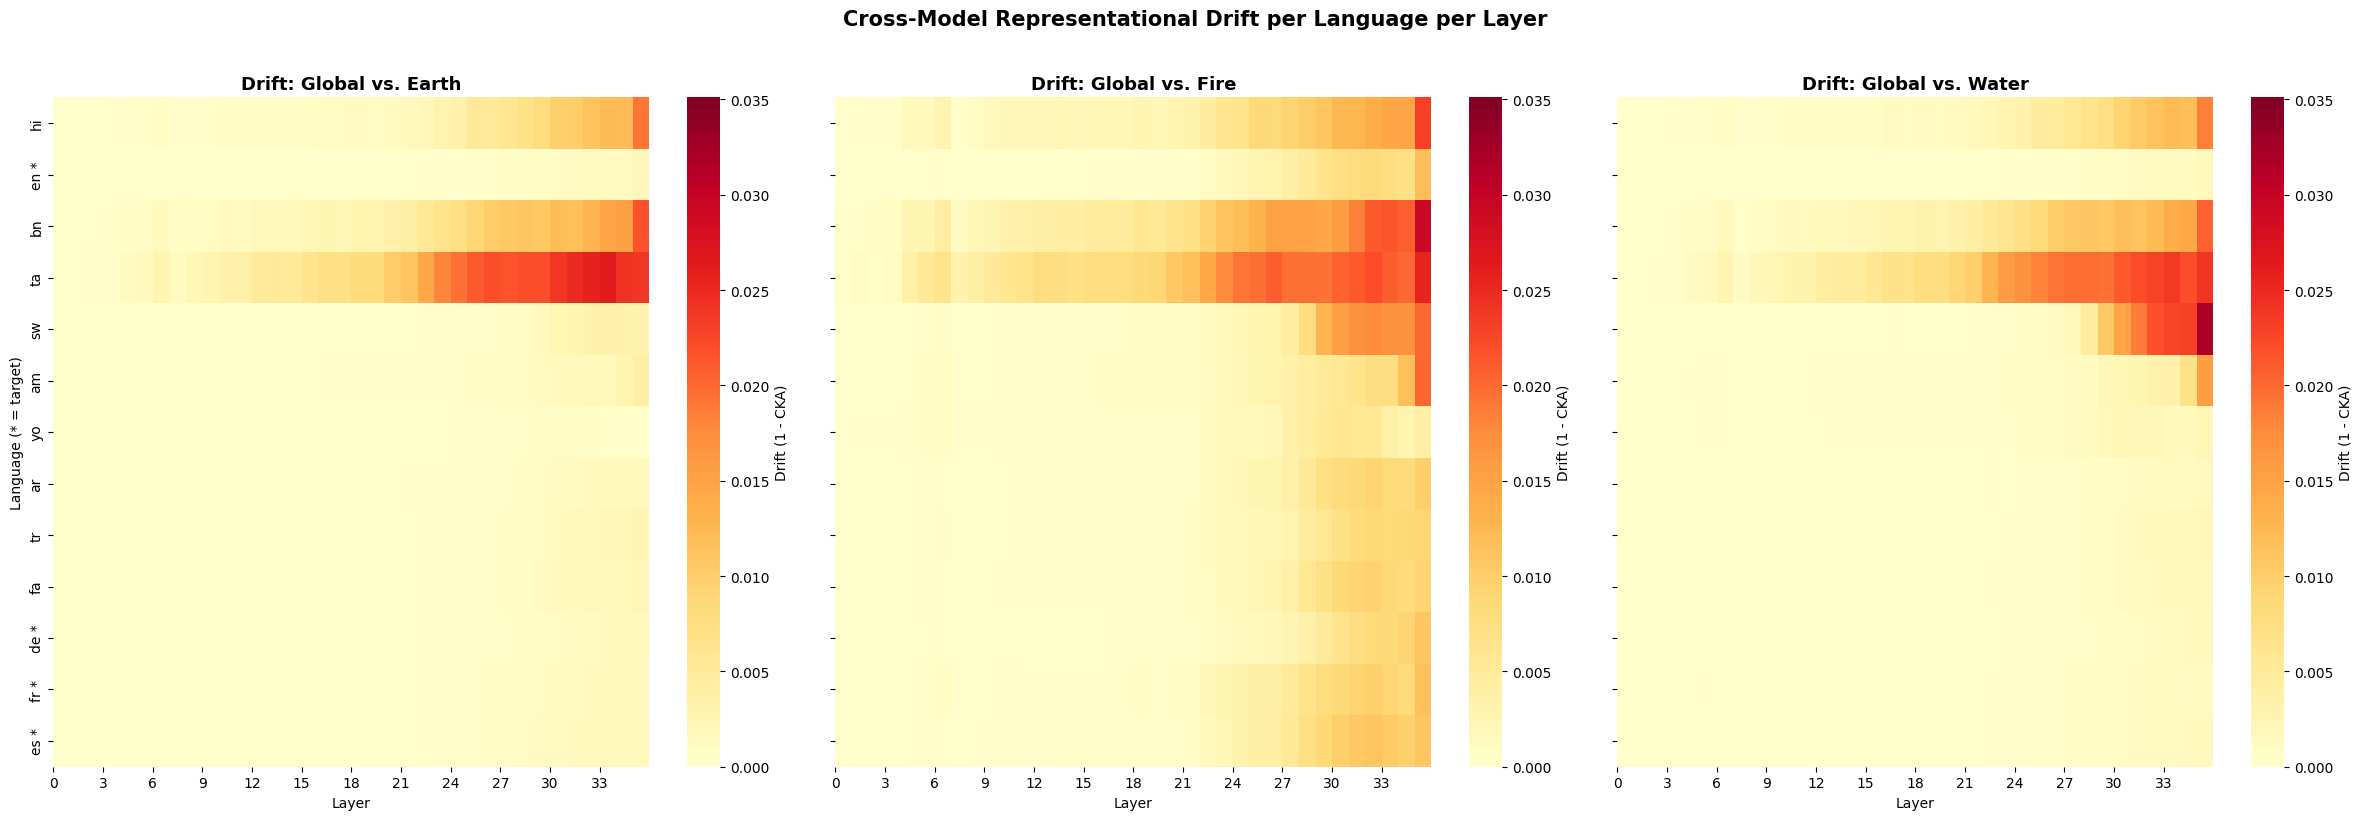

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

for ax_idx, (regional_name, drift_matrix) in enumerate(drift_results.items()):
    # Mark target languages with asterisks.
    y_labels = []
    for lang_name, iso in zip(language_names, iso_codes):
        is_target = LANGUAGE_REGION_MAP.get(lang_name) == regional_name
        y_labels.append(f"{iso} *" if is_target else iso)

    # Subsample layer ticks for readability.
    x_ticks = list(range(0, n_layers, max(1, n_layers // 12)))

    sns.heatmap(
        drift_matrix,
        ax=axes[ax_idx],
        yticklabels=y_labels,
        xticklabels=False,
        cmap="YlOrRd",
        vmin=0,
        vmax=max(dm.max() for dm in drift_results.values()) * 1.1,
        cbar_kws={"label": "Drift (1 - CKA)"},
    )
    axes[ax_idx].set_xticks(x_ticks)
    axes[ax_idx].set_xticklabels(x_ticks)
    axes[ax_idx].set_xlabel("Layer")
    axes[ax_idx].set_title(
        f"Drift: Global vs. {regional_name.title()}",
        fontsize=13, fontweight="bold",
    )

axes[0].set_ylabel("Language (* = target)")
plt.suptitle(
    "Cross-Model Representational Drift per Language per Layer",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "drift_heatmaps.png", bbox_inches="tight", dpi=150)
plt.show()

## 4. Target vs. Non-Target Drift Comparison

For each regional model, compare average drift of target languages
vs. non-target languages across layers. This is the core test of
our hypothesis: do regional models preferentially change their
target-language representations?

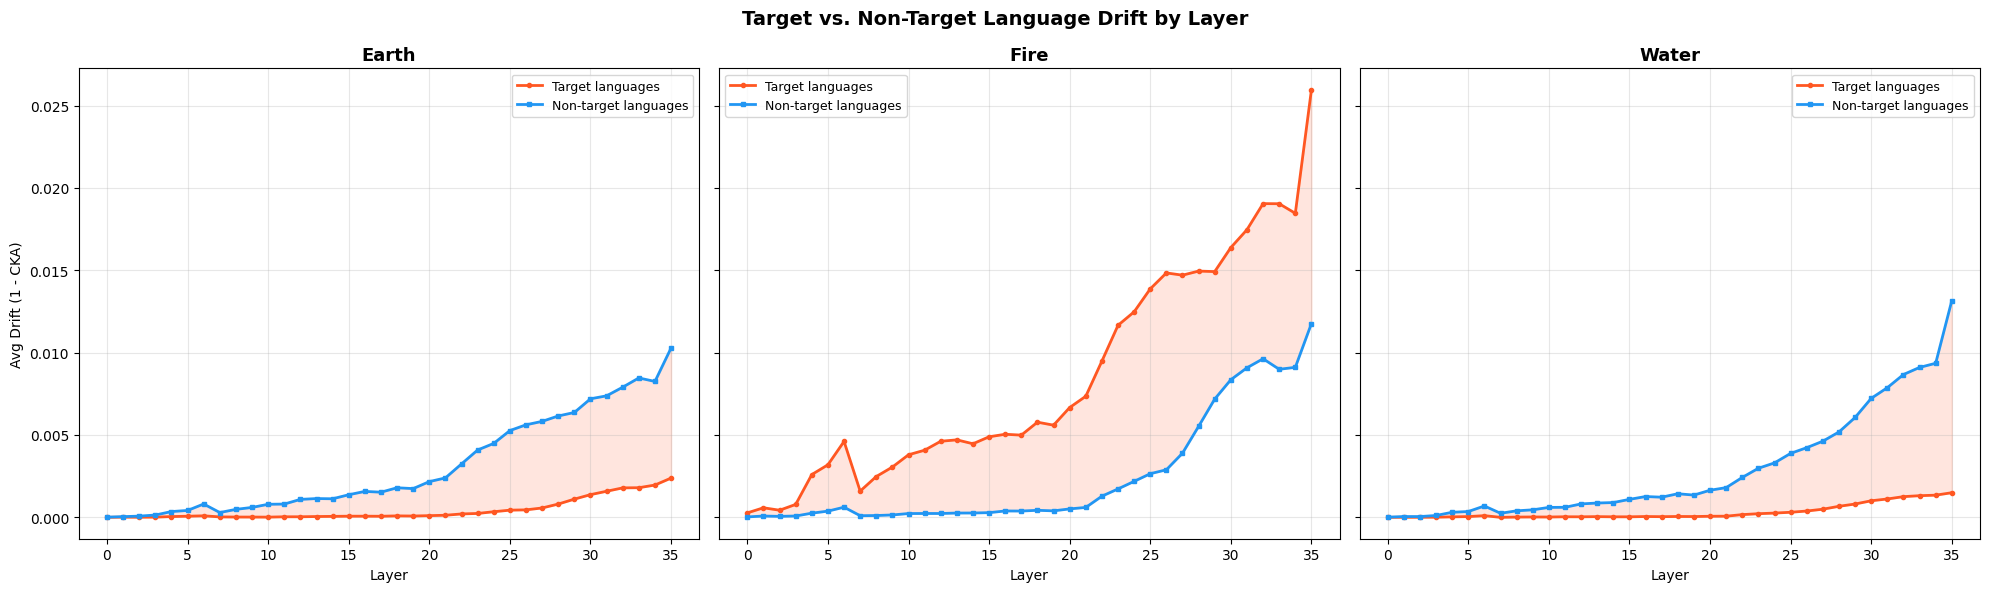


Target vs. Non-target drift summary:
  earth : target=0.000448  non-target=0.003091  ratio=0.14x
  fire  : target=0.008468  non-target=0.002508  ratio=3.38x
  water : target=0.000321  non-target=0.002898  ratio=0.11x


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

target_nontarget_stats: dict[str, dict[str, float]] = {}

for ax_idx, (regional_name, drift_matrix) in enumerate(drift_results.items()):
    target_mask = np.array([
        LANGUAGE_REGION_MAP.get(lang) == regional_name
        for lang in language_names
    ])

    target_drift = drift_matrix[target_mask].mean(axis=0)
    nontarget_drift = drift_matrix[~target_mask].mean(axis=0)

    layers = np.arange(n_layers)
    axes[ax_idx].plot(layers, target_drift, "o-", color="#FF5722",
                      linewidth=2, markersize=3, label="Target languages")
    axes[ax_idx].plot(layers, nontarget_drift, "s-", color="#2196F3",
                      linewidth=2, markersize=3, label="Non-target languages")
    axes[ax_idx].fill_between(layers, target_drift, nontarget_drift,
                              alpha=0.15, color="#FF5722")

    axes[ax_idx].set_xlabel("Layer")
    axes[ax_idx].set_title(f"{regional_name.title()}", fontsize=13, fontweight="bold")
    axes[ax_idx].legend(fontsize=9)
    axes[ax_idx].grid(True, alpha=0.3)

    target_nontarget_stats[regional_name] = {
        "target_avg_drift": float(drift_matrix[target_mask].mean()),
        "nontarget_avg_drift": float(drift_matrix[~target_mask].mean()),
        "drift_ratio": float(
            drift_matrix[target_mask].mean() / max(drift_matrix[~target_mask].mean(), 1e-10)
        ),
    }

axes[0].set_ylabel("Avg Drift (1 - CKA)")
plt.suptitle(
    "Target vs. Non-Target Language Drift by Layer",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "drift_target_vs_nontarget.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nTarget vs. Non-target drift summary:")
for rname, stats in target_nontarget_stats.items():
    print(
        f"  {rname:6s}: target={stats['target_avg_drift']:.6f}  "
        f"non-target={stats['nontarget_avg_drift']:.6f}  "
        f"ratio={stats['drift_ratio']:.2f}x"
    )

---

# Part 2: Per-Language Retrieval MRR Comparison

We now compute translation retrieval MRR for each model at each
layer, using English as the source language. This measures
**functional alignment**: can we find a sentence's translation
by nearest-neighbor search in the embedding space?

If regional models improve representations for their target
languages, we expect higher MRR for those languages compared
to the Global model.

## 5. Compute Retrieval MRR for All Models

In [8]:
# retrieval_results: {model_name: {layer_idx: {lang_name: {metric: value}}}}
retrieval_results: dict[str, dict[int, dict[str, dict[str, float]]]] = {}

for model_name in REGIONAL_MODELS:
    print(f"\n=== Retrieval metrics: {model_name} ===")
    model_retrieval: dict[int, dict[str, dict[str, float]]] = {}

    src_acts = model_activations[model_name][SOURCE_LANG]

    for layer_idx in range(n_layers):
        src_emb = src_acts[layer_idx].numpy()
        layer_results: dict[str, dict[str, float]] = {}

        for lang in languages:
            if lang.lang_name == SOURCE_LANG:
                continue
            tgt_emb = model_activations[model_name][lang.lang_name][layer_idx].numpy()
            metrics = compute_all_retrieval_metrics(src_emb, tgt_emb, k_values=K_VALUES)
            layer_results[lang.lang_name] = metrics

        model_retrieval[layer_idx] = layer_results

    retrieval_results[model_name] = model_retrieval

    # Print best-layer MRR for each language.
    for lang in languages:
        if lang.lang_name == SOURCE_LANG:
            continue
        best_mrr = max(
            model_retrieval[l][lang.lang_name]["mrr"]
            for l in range(n_layers)
        )
        best_layer = max(
            range(n_layers),
            key=lambda l: model_retrieval[l][lang.lang_name]["mrr"],
        )
        is_target = LANGUAGE_REGION_MAP.get(lang.lang_name) == model_name
        marker = "*" if is_target else " "
        print(f"  {marker} {lang.iso_code:<4} best_MRR={best_mrr:.4f} (layer {best_layer})")

print("\n(* = target language for this model)")


=== Retrieval metrics: global ===


    hi   best_MRR=0.1346 (layer 26)
    bn   best_MRR=0.1212 (layer 29)
    ta   best_MRR=0.0741 (layer 26)
    sw   best_MRR=0.8266 (layer 10)
    am   best_MRR=0.2662 (layer 26)
    yo   best_MRR=0.1648 (layer 22)
    ar   best_MRR=0.9601 (layer 26)
    tr   best_MRR=0.9313 (layer 23)
    fa   best_MRR=0.8179 (layer 16)
    de   best_MRR=0.9811 (layer 26)
    fr   best_MRR=0.9637 (layer 26)
    es   best_MRR=0.9771 (layer 25)

=== Retrieval metrics: earth ===
    hi   best_MRR=0.1426 (layer 26)
    bn   best_MRR=0.1183 (layer 29)
    ta   best_MRR=0.0750 (layer 25)
  * sw   best_MRR=0.8393 (layer 17)
  * am   best_MRR=0.2978 (layer 26)
  * yo   best_MRR=0.1724 (layer 22)
  * ar   best_MRR=0.9724 (layer 26)
  * tr   best_MRR=0.9395 (layer 23)
  * fa   best_MRR=0.8257 (layer 18)
    de   best_MRR=0.9887 (layer 25)
    fr   best_MRR=0.9736 (layer 26)
    es   best_MRR=0.9797 (layer 26)

=== Retrieval metrics: fire ===
  * hi   best_MRR=0.1714 (layer 26)
  * bn   best_MRR=0.1506 (layer 2

## 6. MRR Advantage Heatmap (Regional - Global)

For each regional model and language, compute the MRR difference
at the best layer. Positive = regional model is better.

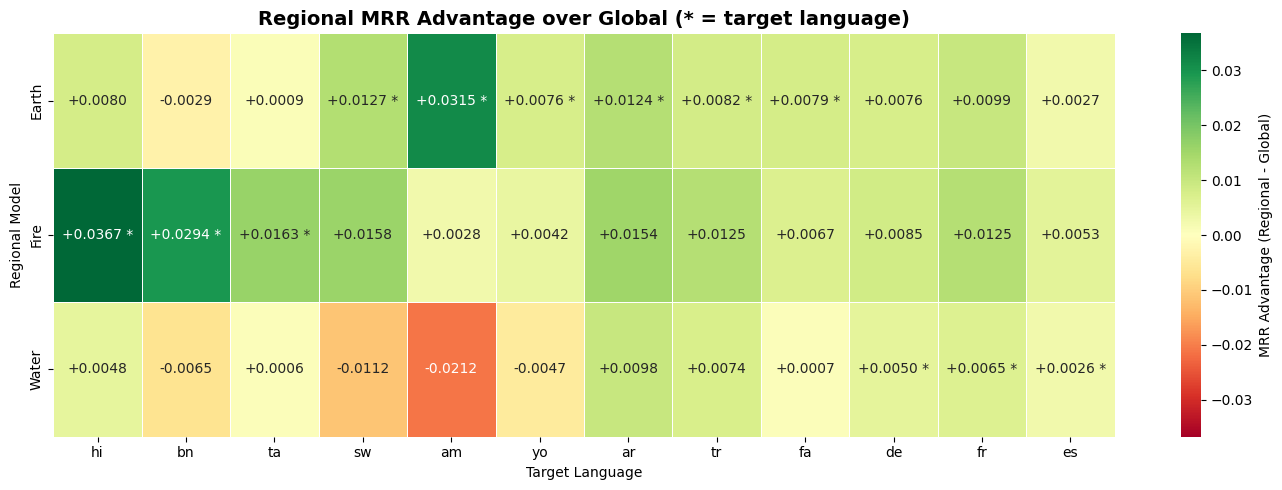


MRR Advantage summary (best-layer MRR, regional - global):
  earth : target_avg=+0.0134  non-target_avg=+0.0044
  fire  : target_avg=+0.0275  non-target_avg=+0.0093
  water : target_avg=+0.0047  non-target_avg=-0.0023


In [9]:
# Compute per-language best-layer MRR for each model.
# mrr_best: {model_name: {lang_name: best_mrr}}
target_langs = [l.lang_name for l in languages if l.lang_name != SOURCE_LANG]

mrr_best: dict[str, dict[str, float]] = {}
for model_name in REGIONAL_MODELS:
    mrr_best[model_name] = {}
    for lang_name in target_langs:
        mrr_best[model_name][lang_name] = max(
            retrieval_results[model_name][l][lang_name]["mrr"]
            for l in range(n_layers)
        )

# Build advantage matrix: (n_regional_models x n_target_langs)
regional_names = ["earth", "fire", "water"]
advantage_matrix = np.zeros((len(regional_names), len(target_langs)))

for i, rname in enumerate(regional_names):
    for j, lang_name in enumerate(target_langs):
        advantage_matrix[i, j] = (
            mrr_best[rname][lang_name] - mrr_best["global"][lang_name]
        )

# Plot.
fig, ax = plt.subplots(figsize=(14, 5))
target_isos = [
    next(l.iso_code for l in languages if l.lang_name == ln)
    for ln in target_langs
]

# Annotate target languages with boxes.
annot_labels = np.empty_like(advantage_matrix, dtype=object)
for i, rname in enumerate(regional_names):
    for j, lang_name in enumerate(target_langs):
        val = advantage_matrix[i, j]
        is_target = LANGUAGE_REGION_MAP.get(lang_name) == rname
        annot_labels[i, j] = f"{val:+.4f}" + (" *" if is_target else "")

vmax = max(abs(advantage_matrix.min()), abs(advantage_matrix.max()), 0.01)
sns.heatmap(
    advantage_matrix,
    ax=ax,
    xticklabels=target_isos,
    yticklabels=[n.title() for n in regional_names],
    annot=annot_labels,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    linewidths=0.5,
    cbar_kws={"label": "MRR Advantage (Regional - Global)"},
)
ax.set_title(
    "Regional MRR Advantage over Global (* = target language)",
    fontsize=14, fontweight="bold",
)
ax.set_xlabel("Target Language")
ax.set_ylabel("Regional Model")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "mrr_advantage_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

# Print summary.
print("\nMRR Advantage summary (best-layer MRR, regional - global):")
for i, rname in enumerate(regional_names):
    target_adv = [advantage_matrix[i, j] for j, ln in enumerate(target_langs)
                  if LANGUAGE_REGION_MAP.get(ln) == rname]
    nontarget_adv = [advantage_matrix[i, j] for j, ln in enumerate(target_langs)
                     if LANGUAGE_REGION_MAP.get(ln) != rname]
    print(
        f"  {rname:6s}: target_avg={np.mean(target_adv):+.4f}  "
        f"non-target_avg={np.mean(nontarget_adv):+.4f}"
    )

## 7. Per-Language MRR Curves Across Models

Plot MRR vs. layer for each target language, with one line per
model. This shows at which layers each regional model helps or
hurts retrieval performance.

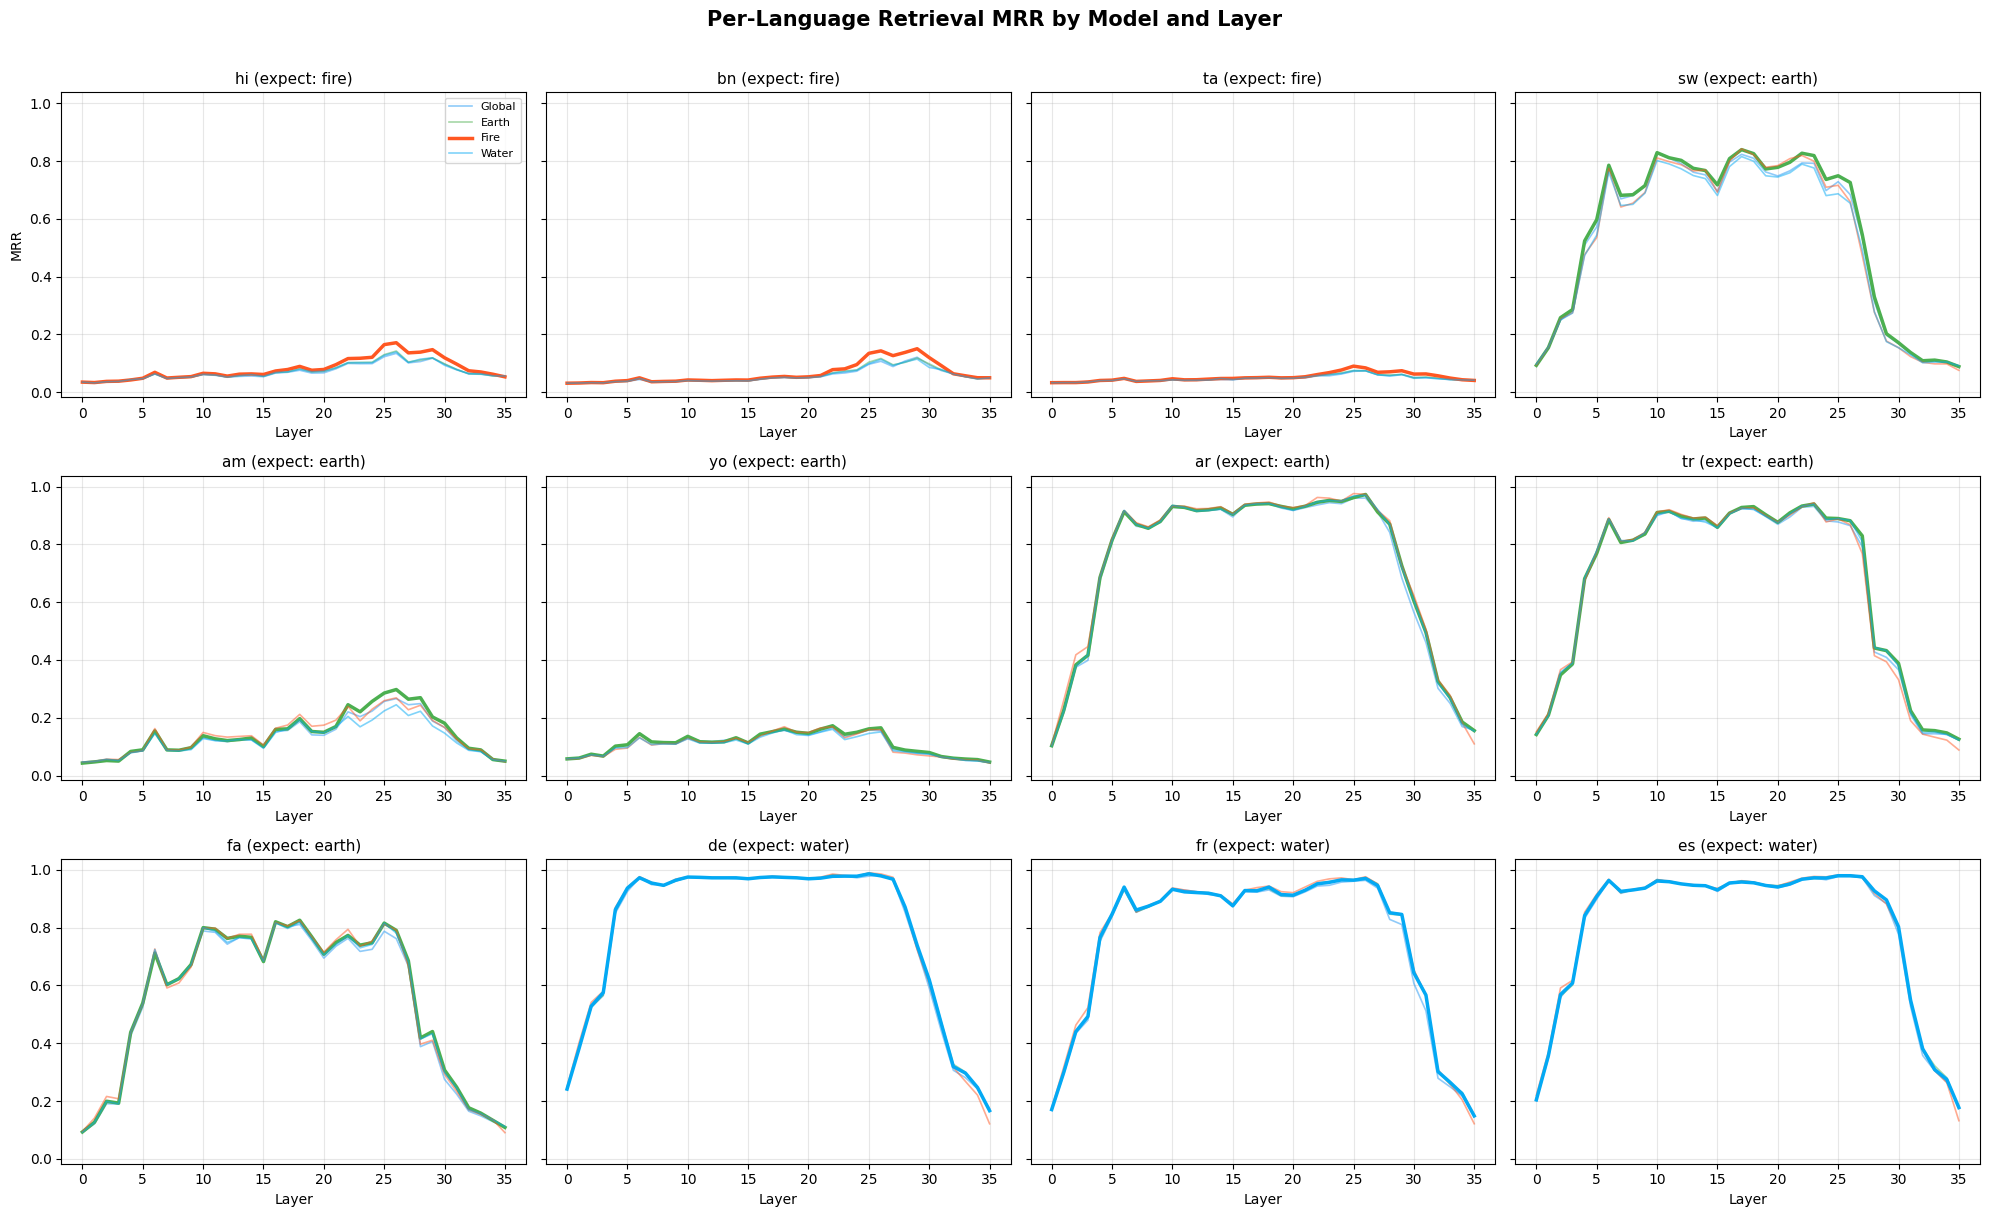

In [10]:
model_colors = {
    "global": "#2196F3",
    "earth": "#4CAF50",
    "fire": "#FF5722",
    "water": "#03A9F4",
}

n_target = len(target_langs)
ncols = 4
nrows = (n_target + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), sharey=True)
axes_flat = axes.flatten()

for idx, lang_name in enumerate(target_langs):
    ax = axes_flat[idx]
    for model_name in REGIONAL_MODELS:
        mrr_values = [
            retrieval_results[model_name][l][lang_name]["mrr"]
            for l in range(n_layers)
        ]
        is_best = LANGUAGE_REGION_MAP.get(lang_name) == model_name
        ax.plot(
            range(n_layers), mrr_values,
            color=model_colors[model_name],
            linewidth=2.5 if is_best else 1.2,
            alpha=1.0 if is_best else 0.5,
            label=model_name.title(),
        )

    iso = next(l.iso_code for l in languages if l.lang_name == lang_name)
    expected = LANGUAGE_REGION_MAP.get(lang_name, "?")
    ax.set_title(f"{iso} (expect: {expected})", fontsize=11)
    ax.set_xlabel("Layer")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

# Hide unused subplots.
for idx in range(n_target, len(axes_flat)):
    axes_flat[idx].set_visible(False)

axes_flat[0].set_ylabel("MRR")
plt.suptitle(
    "Per-Language Retrieval MRR by Model and Layer",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "mrr_per_language_all_models.png", bbox_inches="tight", dpi=150)
plt.show()

---

# Part 3: Drift-MRR Correlation

The key question: **does representational drift predict functional
improvement?** We correlate each language's average drift with its
MRR advantage (regional - global) to test whether the geometric
changes made by regional models actually help.

## 8. Drift vs. MRR Advantage Scatter Plot

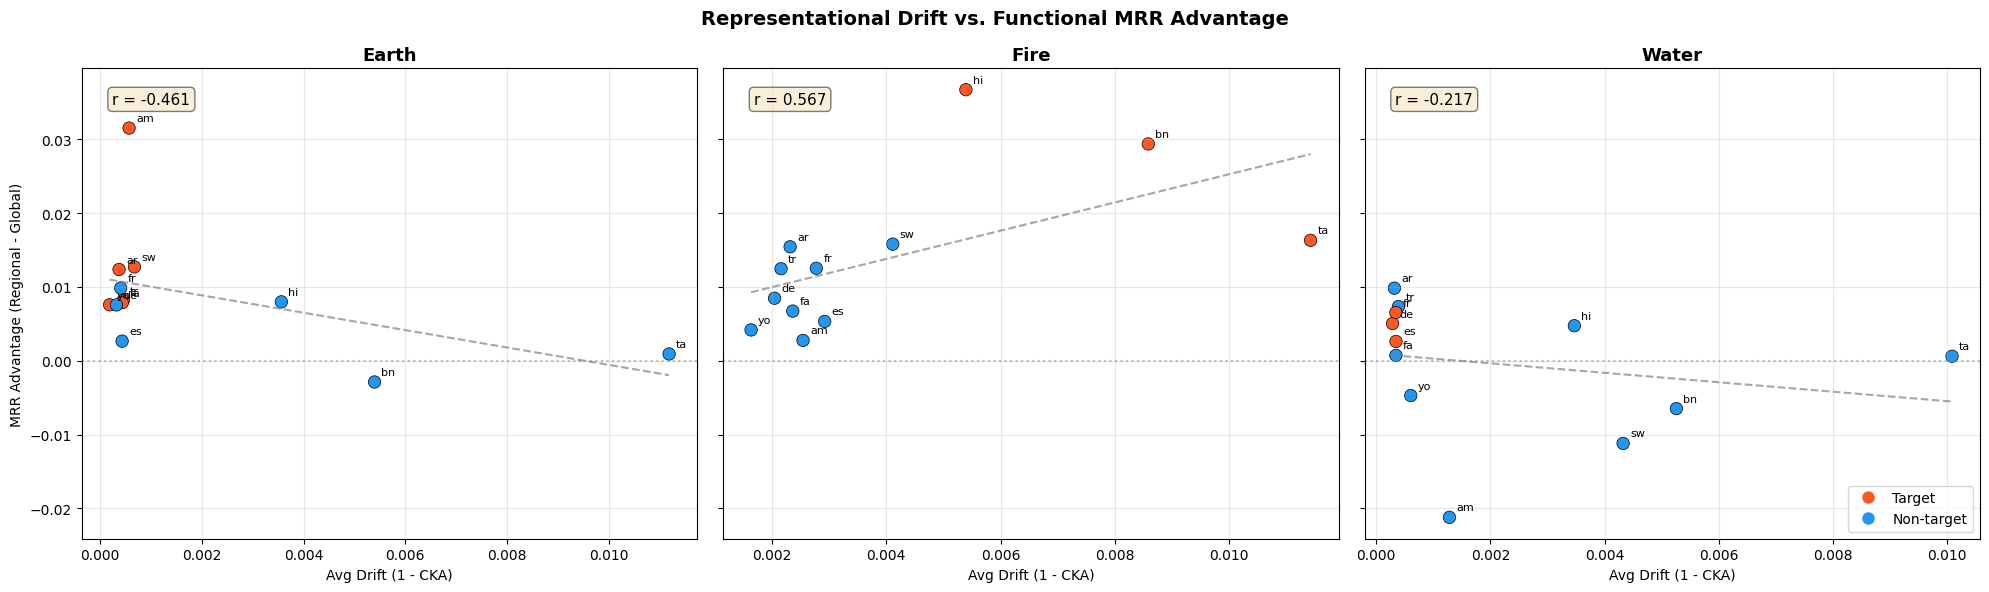


Overall Pearson correlation (all models pooled): r = 0.098
  earth : r = -0.461, slope = -1.18
  fire  : r = 0.567, slope = 1.91
  water : r = -0.217, slope = -0.64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

all_drifts = []
all_advantages = []
correlation_results: dict[str, dict[str, float]] = {}

for ax_idx, rname in enumerate(regional_names):
    drift_matrix = drift_results[rname]
    drifts = []
    advantages = []
    labels = []
    colors = []

    for j, lang_name in enumerate(target_langs):
        lang_idx = language_names.index(lang_name)
        avg_drift = float(drift_matrix[lang_idx, :].mean())
        mrr_adv = mrr_best[rname][lang_name] - mrr_best["global"][lang_name]

        drifts.append(avg_drift)
        advantages.append(mrr_adv)
        iso = next(l.iso_code for l in languages if l.lang_name == lang_name)
        labels.append(iso)

        is_target = LANGUAGE_REGION_MAP.get(lang_name) == rname
        colors.append("#FF5722" if is_target else "#2196F3")

    all_drifts.extend(drifts)
    all_advantages.extend(advantages)

    drifts_arr = np.array(drifts)
    adv_arr = np.array(advantages)

    axes[ax_idx].scatter(drifts_arr, adv_arr, c=colors, s=80, edgecolors="k", linewidth=0.5)
    for k, label in enumerate(labels):
        axes[ax_idx].annotate(label, (drifts_arr[k], adv_arr[k]),
                              textcoords="offset points", xytext=(5, 5), fontsize=8)

    # Fit regression line.
    if len(drifts_arr) > 2 and drifts_arr.std() > 0:
        corr = np.corrcoef(drifts_arr, adv_arr)[0, 1]
        m, b = np.polyfit(drifts_arr, adv_arr, 1)
        x_line = np.linspace(drifts_arr.min(), drifts_arr.max(), 50)
        axes[ax_idx].plot(x_line, m * x_line + b, "--", color="gray", alpha=0.7)
        axes[ax_idx].text(
            0.05, 0.95, f"r = {corr:.3f}",
            transform=axes[ax_idx].transAxes, fontsize=11,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )
        correlation_results[rname] = {
            "pearson_r": float(corr),
            "slope": float(m),
            "intercept": float(b),
        }

    axes[ax_idx].axhline(y=0, color="gray", linestyle=":", alpha=0.5)
    axes[ax_idx].set_xlabel("Avg Drift (1 - CKA)")
    axes[ax_idx].set_title(f"{rname.title()}", fontsize=13, fontweight="bold")
    axes[ax_idx].grid(True, alpha=0.3)

axes[0].set_ylabel("MRR Advantage (Regional - Global)")
plt.suptitle(
    "Representational Drift vs. Functional MRR Advantage",
    fontsize=14, fontweight="bold",
)

# Legend for target/non-target.
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#FF5722",
           markersize=10, label="Target"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2196F3",
           markersize=10, label="Non-target"),
]
axes[2].legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "drift_vs_mrr_advantage.png", bbox_inches="tight", dpi=150)
plt.show()

# Overall correlation.
overall_corr = np.corrcoef(all_drifts, all_advantages)[0, 1]
print(f"\nOverall Pearson correlation (all models pooled): r = {overall_corr:.3f}")
for rname, stats in correlation_results.items():
    print(f"  {rname:6s}: r = {stats['pearson_r']:.3f}, slope = {stats['slope']:.2f}")

## 9. Regional Advantage Table

For each language, which model gives the best MRR? This is the
**Regional Advantage Table** — the practical takeaway showing
which model to use for each language.

In [12]:
print(f"{'Language':<12} {'Expected':>10} {'Best Model':>12} {'Best MRR':>10} {'Global MRR':>12} {'Advantage':>12} {'Match?':>8}")
print("-" * 80)

matches = 0
for lang_name in target_langs:
    iso = next(l.iso_code for l in languages if l.lang_name == lang_name)
    expected_model = LANGUAGE_REGION_MAP.get(lang_name, "?")

    best_model = max(REGIONAL_MODELS.keys(), key=lambda m: mrr_best[m][lang_name])
    best_mrr_val = mrr_best[best_model][lang_name]
    global_mrr_val = mrr_best["global"][lang_name]
    advantage = best_mrr_val - global_mrr_val
    match = "yes" if best_model == expected_model else "no"
    if best_model == expected_model:
        matches += 1

    print(
        f"{iso:<12} {expected_model:>10} {best_model:>12} {best_mrr_val:>10.4f} "
        f"{global_mrr_val:>12.4f} {advantage:>+12.4f} {match:>8}"
    )

print(f"\nExpected-region match rate: {matches}/{len(target_langs)} "
      f"({100*matches/len(target_langs):.0f}%)")

Language       Expected   Best Model   Best MRR   Global MRR    Advantage   Match?
--------------------------------------------------------------------------------
hi                 fire         fire     0.1714       0.1346      +0.0367      yes
bn                 fire         fire     0.1506       0.1212      +0.0294      yes
ta                 fire         fire     0.0904       0.0741      +0.0163      yes
sw                earth         fire     0.8424       0.8266      +0.0158       no
am                earth        earth     0.2978       0.2662      +0.0315      yes
yo                earth        earth     0.1724       0.1648      +0.0076      yes
ar                earth         fire     0.9755       0.9601      +0.0154       no
tr                earth         fire     0.9438       0.9313      +0.0125       no
fa                earth        earth     0.8257       0.8179      +0.0079      yes
de                water         fire     0.9896       0.9811      +0.0085       no
fr    

---

## 10. Save Metrics

In [13]:
metrics = {
    "drift": {},
    "mrr_best": {},
    "mrr_advantage": {},
    "target_nontarget_stats": target_nontarget_stats,
    "correlation": correlation_results,
}

# Drift per model per language (averaged across layers).
for rname, drift_matrix in drift_results.items():
    metrics["drift"][rname] = {
        lang_name: float(drift_matrix[i, :].mean())
        for i, lang_name in enumerate(language_names)
    }

# Best MRR per model per language.
for model_name in REGIONAL_MODELS:
    metrics["mrr_best"][model_name] = {
        lang_name: float(mrr_best[model_name][lang_name])
        for lang_name in target_langs
    }

# MRR advantage (regional - global).
for rname in regional_names:
    metrics["mrr_advantage"][rname] = {
        lang_name: float(mrr_best[rname][lang_name] - mrr_best["global"][lang_name])
        for lang_name in target_langs
    }

with open(METRICS_DIR / "cross_model_drift.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to {METRICS_DIR / 'cross_model_drift.json'}")

Metrics saved to /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood/analysis/results/cross_lingual/metrics/cross_model_drift.json


## 11. Summary

### Hypothesis revisited

We tested whether regional fine-tuning makes targeted representational
changes that improve functional alignment for target languages without
disrupting overall cross-lingual geometry. The results are **mixed and
surprising** — the hypothesis is partially confirmed but with important
caveats.

### Part 1: Cross-Model Representational Drift

**Per-language drift (avg across all 36 layers):**

| Language  | Earth avg drift | Fire avg drift | Water avg drift |
|-----------|----------------|---------------|----------------|
| hindi     | 0.003563       | 0.005394*     | 0.003471       |
| english   | 0.000335       | 0.002198      | 0.000310*      |
| bengali   | 0.005395       | 0.008585*     | 0.005258       |
| tamil     | 0.011188       | 0.011424*     | 0.010088       |
| swahili   | 0.000674*      | 0.004114      | 0.004326       |
| amharic   | 0.000568*      | 0.002545      | 0.001283       |
| yoruba    | 0.000186*      | 0.001636      | 0.000605       |
| arabic    | 0.000371*      | 0.002319      | 0.000318       |
| turkish   | 0.000454*      | 0.002160      | 0.000389       |
| persian   | 0.000435*      | 0.002365      | 0.000344       |
| german    | 0.000321       | 0.002047      | 0.000286*      |
| french    | 0.000403       | 0.002777      | 0.000344*      |
| spanish   | 0.000431       | 0.002924      | 0.000346*      |

(* = target language for that regional model)

**Target vs. non-target drift summary:**

| Model | Target avg drift | Non-target avg drift | Ratio |
|-------|-----------------|---------------------|-------|
| **Fire** (South Asia) | 0.008468 | 0.002508 | **3.38x** |
| **Earth** (West Asia + Africa) | 0.000448 | 0.003091 | 0.14x |
| **Water** (Europe + Asia Pacific) | 0.000321 | 0.002898 | 0.11x |

**Fire is the only model that preferentially drifts its target languages.**
Its target-language drift (hi: 0.005394, bn: 0.008585, ta: 0.011424) is
3.38x higher than non-target drift — exactly what we hypothesized. But
Earth and Water show the *opposite* pattern: their non-target languages
drift more than their target languages. This suggests Earth and Water use
a different merging strategy that preserves target-language representations
while allowing non-target representations to shift.

Drift concentrates in later layers (peaks at layers 30-35) for all models,
consistent with the architecture's global-attention layers being more
susceptible to fine-tuning. Tamil and Bengali show the highest drift
across *all* regional models — likely because these low-resource,
non-Latin-script languages have less stable representations overall.

### Part 2: Per-Language Retrieval MRR

**Best-layer MRR per model per language:**

| Language | Global MRR | Earth MRR | Fire MRR  | Water MRR | Best Model |
|----------|-----------|-----------|-----------|-----------|------------|
| hi       | 0.1346    | 0.1426    | **0.1714**| 0.1394    | Fire       |
| bn       | 0.1212    | 0.1183    | **0.1506**| 0.1147    | Fire       |
| ta       | 0.0741    | 0.0750    | **0.0904**| 0.0747    | Fire       |
| sw       | 0.8266    | 0.8393    | **0.8424**| 0.8154    | Fire       |
| am       | 0.2662    | **0.2978**| 0.2690    | 0.2450    | Earth      |
| yo       | 0.1648    | **0.1724**| 0.1690    | 0.1601    | Earth      |
| ar       | 0.9601    | 0.9724    | **0.9755**| 0.9699    | Fire       |
| tr       | 0.9313    | 0.9395    | **0.9438**| 0.9387    | Fire       |
| fa       | 0.8179    | **0.8257**| 0.8246    | 0.8186    | Earth      |
| de       | 0.9811    | 0.9887    | **0.9896**| 0.9862    | Fire       |
| fr       | 0.9637    | 0.9736    | **0.9763**| 0.9703    | Fire       |
| es       | 0.9771    | 0.9797    | **0.9824**| 0.9797    | Fire       |

Every regional model improves MRR for most languages, but **Fire
dominates universally**:

| Model | Target MRR gain | Non-target MRR gain |
|-------|----------------|--------------------|
| **Fire** | **+0.0275** | +0.0093 |
| Earth | +0.0134 | +0.0044 |
| Water | +0.0047 | -0.0023 |

Fire achieves the highest MRR for **9 of 12 target languages** (excluding
English as source). It beats Global by +0.0367 for Hindi, +0.0294 for
Bengali, +0.0163 for Tamil — but also +0.0154 for Arabic, +0.0125 for
Turkish, and +0.0085 for German. The expected-region match rate is only
50% (6/12): Fire takes languages expected to belong to Earth (sw, ar, tr)
and Water (de, fr, es).

Earth is the best model for 3 targets (am: +0.0315, yo: +0.0076,
fa: +0.0079) but loses the higher-resource ones (ar, tr, sw) to Fire.
Water is the weakest regional model, with its target languages (de, fr, es)
already near ceiling on MRR (de=0.9862, fr=0.9703, es=0.9797) where
improvements are hard to measure.

### Part 3: Drift-MRR Correlation

The drift-to-function link is **model-dependent**:

| Model | Pearson r | Slope | Interpretation |
|-------|-----------|-------|----------------|
| Fire | **+0.567** | +1.91 | Drift predicts improvement |
| Earth | -0.461 | -1.18 | Drift predicts *worse* performance |
| Water | -0.217 | -0.64 | No clear relationship |
| Overall | +0.098 | — | Near zero when pooled |

For Fire, higher drift correlates with larger MRR gains (r=+0.567),
confirming that Fire's representational changes are *purposeful*.
For Earth, the negative correlation (r=-0.461) suggests that drift
is *incidental* — the languages that drift most (hi, bn, ta) are
not Earth's targets and don't benefit from its changes.

### Cross-notebook synthesis (Notebooks 08 + 09)

Together, these notebooks reveal a complete picture of how regional
model merging works in Tiny Aya:

1. **Cross-lingual geometry is preserved** (NB 08): Delta-CKA ~0.0001
   confirms that model merging does not disrupt the pairwise similarity
   structure between languages. All four models embed languages in
   essentially the same relative arrangement.

2. **Per-language representations do shift** (NB 09 Part 1): Drift
   analysis reveals small but real per-language changes, peaking in
   later layers. Fire shows preferential target drift (3.38x ratio);
   Earth and Water do not.

3. **Functional improvements are real but non-specific** (NB 09 Part 2):
   Fire improves retrieval MRR for *all* languages, not just its targets.
   This suggests Fire's South Asian data mixture benefits the model
   broadly — possibly because it adds diversity to the training signal.

4. **The Fire model paradox**: Fire is simultaneously the most drifted
   *and* the most functionally improved model across the board. This
   challenges the assumption that regional models are specialized;
   instead, Fire may simply be the best-trained variant overall.

**Implications for practitioners**: When choosing a Tiny Aya variant
for multilingual tasks on these 13 languages, Fire appears to be the
best choice regardless of target language — a counterintuitive finding
that warrants further investigation with task-specific evaluation
(e.g., ChrF/COMET translation scores, as in the tech report).